In [ ]:
import subprocess
import uproot
import os
import time
import requests
from concurrent.futures import ThreadPoolExecutor, as_completed
import numpy as np
import matplotlib.pylab as plt
import awkward as ak
import vector
import json
import boost_histogram as bh

vector.register_awkward()

In [2]:
SAMPLES = {
    "Run2016G": {"recid": 30529, "is_data": True},
    "Run2016H": {"recid": 30562, "is_data": True},
    "DY_inclusive_NLO": {"recid": 35669, "is_data": False, "is_dy": True, "group": "DY"},
    "DY_inclusive_LO":  {"recid": 35671, "is_data": False, "is_dy": True, "group": "DY"},

    # Diboson -- leptonic/semi-leptonic decay channels only, chosen to avoid
    # double-counting with each other or with the inclusive WW/WZ/ZZ samples.
    "WW_2L2Nu":     {"recid": 72676, "is_data": False, "is_dy": False, "group": "diboson"},
    "WZ_3LNu":      {"recid": 72752, "is_data": False, "is_dy": False, "group": "diboson"},
    "WZ_2Q2L":      {"recid": 72742, "is_data": False, "is_dy": False, "group": "diboson"},
    "ZZ_2L2Nu":     {"recid": 75567, "is_data": False, "is_dy": False, "group": "diboson"},
    "ZZ_2Q2L":      {"recid": 75573, "is_data": False, "is_dy": False, "group": "diboson"},
    "ZZ_4L":        {"recid": 75589, "is_data": False, "is_dy": False, "group": "diboson"},
}

CACHE_DIR = "/data/atlas/users/lvdurenw/nano_cache"
branches = [
    "run", "luminosityBlock", "event",
    "Electron_pt", "Electron_eta", "Electron_phi", "Electron_mass",
    "Electron_charge", "Electron_cutBased",
]
branches_mc_extra = [
    "genWeight", "L1PreFiringWeight_Nom", "Pileup_nTrueInt",
    "LHEPart_pdgId", "LHEPart_status",
]
TRIGGER = "HLT_Ele27_WPTight_Gsf"

def human_size(n_bytes):
    for unit in ["B", "KB", "MB", "GB", "TB"]:
        if n_bytes < 1024:
            return f"{n_bytes:.1f} {unit}"
        n_bytes /= 1024
    return f"{n_bytes:.1f} PB"

In [3]:
XSEC_PB = {
    "DY_inclusive_NLO": 6077.22,
    "DY_inclusive_LO":  6077.22,

    # TODO: verify each against its opendata.cern.ch record's own quoted xsec
    "WW_2L2Nu": 12.178,
    "WZ_3LNu":  4.42965,
    "WZ_2Q2L":  5.595,
    "ZZ_2L2Nu": 0.564,
    "ZZ_2Q2L":  3.688,
    "ZZ_4L":    1.256,
}

# Get this from GRL using brilcalc lumi -c web --begin 278820 --end 284044 -i datasets/GRL/GRL.txt -u /fb > log.txt
LUMI_PB = 16290.713420

In [4]:
json_path = "../datasets/GRL/GRL.txt"
json_url = "https://opendata.cern.ch/record/14220/files/Cert_271036-284044_13TeV_Legacy2016_Collisions16_JSON.txt"

if not os.path.exists(json_path):
    resp = requests.get(json_url)
    resp.raise_for_status()
    with open(json_path, "wb") as f:
        f.write(resp.content)

with open(json_path) as f:
    golden_json_raw = json.load(f)

golden_json = {int(run): ranges for run, ranges in golden_json_raw.items()}
print(f"Loaded {len(golden_json)} certified runs")

Loaded 393 certified runs


In [5]:
def lumi_mask(runs, lumis, json_dict):
    """Boolean mask: True where (run, luminosityBlock) falls in a certified range."""
    runs_np = ak.to_numpy(runs)
    lumis_np = ak.to_numpy(lumis)
    mask = np.zeros(len(runs_np), dtype=bool)

    for run in np.unique(runs_np):
        run = int(run)
        if run not in json_dict:
            continue
        run_sel = runs_np == run
        lumi_vals = lumis_np[run_sel]
        run_mask = np.zeros(len(lumi_vals), dtype=bool)
        for lo, hi in json_dict[run]:
            run_mask |= (lumi_vals >= lo) & (lumi_vals <= hi)
        mask[run_sel] = run_mask

    return mask

In [6]:
for name, info in SAMPLES.items():
    result = subprocess.run(
        ["cernopendata-client", "get-file-locations", "--recid", str(info["recid"]), "--protocol", "http"],
        capture_output=True, text=True, check=True,
    )
    info["file_list"] = [f for f in result.stdout.strip().splitlines() if f]
    print(f"{name}: {len(info['file_list'])} files (recid {info['recid']})")

Run2016G: 71 files (recid 30529)
Run2016H: 80 files (recid 30562)
DY_inclusive_NLO: 41 files (recid 35669)
DY_inclusive_LO: 61 files (recid 35671)
WW_2L2Nu: 7 files (recid 72676)
WZ_3LNu: 31 files (recid 72752)
WZ_2Q2L: 39 files (recid 72742)
ZZ_2L2Nu: 15 files (recid 75567)
ZZ_2Q2L: 14 files (recid 75573)
ZZ_4L: 99 files (recid 75589)


In [7]:
for name, info in SAMPLES.items():
    total_bytes = 0
    sized = 0
    for url in info["file_list"]:
        resp = requests.head(url, allow_redirects=True)
        if resp.status_code == 200 and "Content-Length" in resp.headers:
            total_bytes += int(resp.headers["Content-Length"])
            sized += 1
    print(f"{name}: {sized}/{len(info['file_list'])} files sized, total = {human_size(total_bytes)}")

Run2016G: 71/71 files sized, total = 128.2 GB
Run2016H: 80/80 files sized, total = 111.2 GB
DY_inclusive_NLO: 41/41 files sized, total = 84.9 GB
DY_inclusive_LO: 61/61 files sized, total = 90.6 GB
WW_2L2Nu: 7/7 files sized, total = 4.0 GB
WZ_3LNu: 31/31 files sized, total = 14.4 GB
WZ_2Q2L: 28/39 files sized, total = 14.6 GB
ZZ_2L2Nu: 10/15 files sized, total = 15.4 GB
ZZ_2Q2L: 12/14 files sized, total = 19.8 GB
ZZ_4L: 24/99 files sized, total = 15.4 GB


In [8]:
def download_one(url, sample_dir, retries=5):
    fname = os.path.join(sample_dir, os.path.basename(url))
    if os.path.exists(fname):
        return fname
    for attempt in range(retries):
        resp = requests.get(url, stream=True)
        if resp.status_code == 429:
            wait = int(resp.headers.get("Retry-After", 10))
            time.sleep(wait)
            continue
        resp.raise_for_status()
        with open(fname, "wb") as f:
            for block in resp.iter_content(chunk_size=1 << 20):
                f.write(block)
        return fname
    raise RuntimeError(f"Failed to download {url} after {retries} attempts")

def download_sample(name, file_list, max_workers=8):
    sample_dir = os.path.join(CACHE_DIR, name)
    os.makedirs(sample_dir, exist_ok=True)

    local_paths = []
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {ex.submit(download_one, url, sample_dir): url for url in file_list}
        for i, fut in enumerate(as_completed(futures), 1):
            try:
                local_paths.append(fut.result())
                if i % 10 == 0 or i == len(file_list):
                    print(f"  {name}: [{i}/{len(file_list)}] done")
            except Exception as e:
                print(f"  {name}: FAILED {futures[fut]} — {e}")

    # preserve original file order (as_completed returns them out of order)
    ordered = [os.path.join(sample_dir, os.path.basename(u)) for u in file_list]
    return ordered

for name, info in SAMPLES.items():
    print(f"--- downloading {name} ---")
    info["local_paths"] = download_sample(name, info["file_list"])
    print(f"{name}: {len(info['local_paths'])} files cached locally")

--- downloading Run2016G ---
  Run2016G: [10/71] done
  Run2016G: [20/71] done
  Run2016G: [30/71] done
  Run2016G: [40/71] done
  Run2016G: [50/71] done
  Run2016G: [60/71] done
  Run2016G: [70/71] done
  Run2016G: [71/71] done
Run2016G: 71 files cached locally
--- downloading Run2016H ---
  Run2016H: [10/80] done
  Run2016H: [20/80] done
  Run2016H: [30/80] done
  Run2016H: [40/80] done
  Run2016H: [50/80] done
  Run2016H: [60/80] done
  Run2016H: [70/80] done
  Run2016H: [80/80] done
Run2016H: 80 files cached locally
--- downloading DY_inclusive_NLO ---
  DY_inclusive_NLO: [10/41] done
  DY_inclusive_NLO: [20/41] done
  DY_inclusive_NLO: [30/41] done
  DY_inclusive_NLO: [40/41] done
  DY_inclusive_NLO: [41/41] done
DY_inclusive_NLO: 41 files cached locally
--- downloading DY_inclusive_LO ---
  DY_inclusive_LO: [10/61] done
  DY_inclusive_LO: [20/61] done
  DY_inclusive_LO: [30/61] done
  DY_inclusive_LO: [40/61] done
  DY_inclusive_LO: [50/61] done
  DY_inclusive_LO: [60/61] done
  

In [9]:
def get_sum_genweight(local_paths, treename="Runs", branch="genEventSumw"):
    """Sum genEventSumw across all files -- this is the FULL sample sum,
    not restricted to your selected events, and is required for correct
    MC normalization."""
    total = 0.0
    for p in local_paths:
        with uproot.open(p) as f:
            if treename not in f:
                raise KeyError(f"{treename} tree not found in {p} -- check NanoAOD version")
            total += f[treename][branch].array(library="np").sum()
    return total

for name, info in SAMPLES.items():
    if not info["is_data"]:
        info["sum_genweight"] = get_sum_genweight(info["local_paths"])
        print(f"{name}: sum_genweight = {info['sum_genweight']:.4e}")

DY_inclusive_NLO: sum_genweight = 1.2209e+12
DY_inclusive_LO: sum_genweight = 8.2449e+07
WW_2L2Nu: sum_genweight = 3.2147e+07
WZ_3LNu: sum_genweight = 8.8368e+07
WZ_2Q2L: sum_genweight = 1.2976e+08
ZZ_2L2Nu: sum_genweight = 1.5510e+07
ZZ_2Q2L: sum_genweight = 7.5775e+07
ZZ_4L: sum_genweight = 6.9075e+07


In [10]:
from tqdm.auto import tqdm

def get_total_entries(local_paths, treename="Events"):
    """Fast metadata-only read to get total event count across files."""
    total = 0
    for p in local_paths:
        with uproot.open(p) as f:
            total += f[treename].num_entries
    return total

def classify_dy_channel(lhe_pdgid, lhe_status):
    """Return 'ee', 'mumu', 'tautau', or 'other' based on the LHE-level outgoing lepton flavor."""
    outgoing = lhe_status == 1
    lep_mask = outgoing & (
        (abs(lhe_pdgid) == 11) | (abs(lhe_pdgid) == 13) | (abs(lhe_pdgid) == 15)
    )
    # both leptons in Z->ll share the same |pdgId|, so the first one found is enough
    first_pdgid = ak.to_numpy(ak.firsts(lhe_pdgid[lep_mask]))

    channel = np.select(
        [np.abs(first_pdgid) == 11, np.abs(first_pdgid) == 13, np.abs(first_pdgid) == 15],
        ["ee", "mumu", "tautau"],
        default="other",
    )
    return channel

def process_sample(name, info, branches, chunk_size="200 MB"):
    """Returns a dict with flattened invariant masses and per-event weights."""
    is_data = info["is_data"]
    these_branches = branches + [TRIGGER] + ([] if is_data else branches_mc_extra)

    total_events = get_total_entries(info["local_paths"])

    masses = []
    weights = []
    channels = []

    chunk_iter = uproot.iterate(
        [f"{p}:Events" for p in info["local_paths"]],
        filter_name=these_branches,
        library="ak",
        step_size=chunk_size,
    )

    pbar = tqdm(total=total_events, desc=name, unit="evt", unit_scale=True, leave=True)
    for chunk in chunk_iter:
        n_raw = len(chunk)  # capture before filtering, so the progress bar stays in sync

        trig_mask = chunk[TRIGGER]
        if is_data:
            good_lumi = lumi_mask(chunk["run"], chunk["luminosityBlock"], golden_json)
            event_mask = trig_mask & good_lumi
        else:
            event_mask = trig_mask

        chunk = chunk[event_mask]

        good_e = (chunk["Electron_pt"] > 20) & (abs(chunk["Electron_eta"]) < 2.5) & (chunk["Electron_cutBased"] >= 3)
        n_good = ak.sum(good_e, axis=1)
        two_e_mask = n_good == 2

        sel = chunk[two_e_mask]
        good_mask_sel = good_e[two_e_mask]

        ele = ak.zip({
            "pt": sel["Electron_pt"][good_mask_sel],
            "eta": sel["Electron_eta"][good_mask_sel],
            "phi": sel["Electron_phi"][good_mask_sel],
            "mass": sel["Electron_mass"][good_mask_sel],
            "charge": sel["Electron_charge"][good_mask_sel],
        }, with_name="Momentum4D")

        oppsign = ele[:, 0].charge * ele[:, 1].charge == -1
        ele = ele[oppsign]

        m = (ele[:, 0] + ele[:, 1]).mass
        masses.append(ak.to_numpy(m))

        if is_data:
            weights.append(np.ones(len(m)))
            channels.append(np.full(len(m), "data"))
        else:
            genw = sel["genWeight"][oppsign]
            prefire = sel["L1PreFiringWeight_Nom"][oppsign]

            xsec = XSEC_PB[name]
            if xsec is None or LUMI_PB is None:
                raise ValueError(
                    f"Set XSEC_PB['{name}'] and LUMI_PB before running -- "
                    "MC normalization is not physically meaningful without them."
                )
            norm = xsec * LUMI_PB / info["sum_genweight"]

            w = genw * prefire * norm
            weights.append(ak.to_numpy(w))

            if info.get("is_dy", False):
                ch = classify_dy_channel(sel["LHEPart_pdgId"][oppsign], sel["LHEPart_status"][oppsign])
            else:
                ch = np.full(len(m), info.get("group", name))
            channels.append(ch)

        pbar.update(n_raw)
        pbar.set_postfix(selected=sum(len(x) for x in masses))

    pbar.close()

    return {
        "mass": np.concatenate(masses) if masses else np.array([]),
        "weight": np.concatenate(weights) if weights else np.array([]),
        "channel": np.concatenate(channels) if channels else np.array([]),
    }

results = {}
for name, info in tqdm(SAMPLES.items(), desc="Samples", unit="sample"):
    results[name] = process_sample(name, info, branches)
    print(f"  {name}: {len(results[name]['mass'])} selected events")

Samples:   0%|          | 0/10 [00:00<?, ?sample/s]

Run2016G:   0%|          | 0.00/153M [00:00<?, ?evt/s]

  Run2016G: 3108273 selected events


Run2016H:   0%|          | 0.00/129M [00:00<?, ?evt/s]

  Run2016H: 3452445 selected events


...

  ZZ_2L2Nu: 1015050 selected events


ZZ_2Q2L:   0%|          | 0.00/13.7M [00:00<?, ?evt/s]

  ZZ_2Q2L: 861352 selected events


ZZ_4L:   0%|          | 0.00/52.1M [00:00<?, ?evt/s]

  ZZ_4L: 2472210 selected events


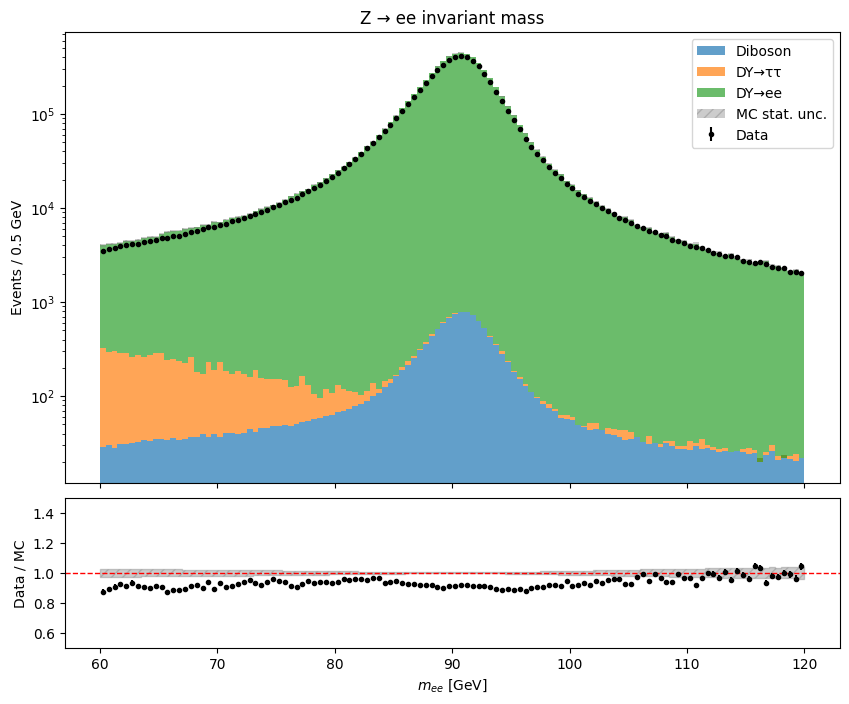

In [15]:
bins = np.linspace(60, 120, 121)
bin_centers = 0.5 * (bins[1:] + bins[:-1])
bin_widths = np.diff(bins)

fig, (ax, ax_ratio) = plt.subplots(
    2, 1, figsize=(10, 8), sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
)

dy = results["DY_inclusive_NLO"]

mc_hists = []
mc_weights_list = []
mc_names = []

# Diboson -- combined into one stack entry
diboson_names = [n for n, info in SAMPLES.items() if info.get("group") == "diboson"]
if diboson_names:
    diboson_mass = np.concatenate([results[n]["mass"] for n in diboson_names])
    diboson_weight = np.concatenate([results[n]["weight"] for n in diboson_names])
    mc_hists.append(diboson_mass)
    mc_weights_list.append(diboson_weight)
    mc_names.append("Diboson")

# DY split by true decay channel, tautau first so ee ends up on top of the stack
for ch, label in [("tautau", "DY→ττ"), ("mumu", "DY→μμ"), ("ee", "DY→ee")]:
    mask = dy["channel"] == ch
    if mask.sum() == 0:
        continue
    mc_hists.append(dy["mass"][mask])
    mc_weights_list.append(dy["weight"][mask])
    mc_names.append(label)

if mc_hists:
    ax.hist(
        mc_hists,
        bins=bins,
        weights=mc_weights_list,
        stacked=True,
        label=mc_names,
        alpha=0.7,
    )

# --- rest of the cell (MC uncertainty band, data, ratio panel) is unchanged ---
all_mc_mass = np.concatenate(mc_hists) if mc_hists else np.array([])
all_mc_weight = np.concatenate(mc_weights_list) if mc_weights_list else np.array([])

mc_counts, _ = np.histogram(all_mc_mass, bins=bins, weights=all_mc_weight)
mc_variance, _ = np.histogram(all_mc_mass, bins=bins, weights=all_mc_weight**2)
mc_err = np.sqrt(mc_variance)

edges_rep = np.repeat(bins, 2)[1:-1]
lower_rep = np.repeat(mc_counts - mc_err, 2)
upper_rep = np.repeat(mc_counts + mc_err, 2)
ax.fill_between(edges_rep, lower_rep, upper_rep, step=None, color="gray",
                 alpha=0.4, hatch="///", edgecolor="none", label="MC stat. unc.")

data_names = [n for n, info in SAMPLES.items() if info["is_data"]]
data_mass = np.concatenate([results[n]["mass"] for n in data_names]) if data_names else np.array([])
data_counts, _ = np.histogram(data_mass, bins=bins)
data_err = np.sqrt(data_counts)

ax.errorbar(bin_centers, data_counts, yerr=data_err, fmt="ko", markersize=3, label="Data")

ax.set_ylabel("Events / 0.5 GeV")
ax.set_yscale("log")
ax.legend()
ax.set_title("Z → ee invariant mass")

with np.errstate(divide="ignore", invalid="ignore"):
    ratio = np.where(mc_counts > 0, data_counts / mc_counts, np.nan)
    ratio_err = np.where(mc_counts > 0, data_err / mc_counts, np.nan)
    mc_rel_err = np.where(mc_counts > 0, mc_err / mc_counts, np.nan)

lower_band = np.repeat(1 - mc_rel_err, 2)
upper_band = np.repeat(1 + mc_rel_err, 2)
ax_ratio.fill_between(edges_rep, lower_band, upper_band, color="gray", alpha=0.4, hatch="///")

ax_ratio.errorbar(bin_centers, ratio, yerr=ratio_err, fmt="ko", markersize=3)
ax_ratio.axhline(1.0, color="red", linestyle="--", linewidth=1)
ax_ratio.set_ylim(0.5, 1.5)
ax_ratio.set_ylabel("Data / MC")
ax_ratio.set_xlabel("$m_{ee}$ [GeV]")

plt.show()

In [ ]:
def make_bh(mass, bins, weight=None):
    h = bh.Histogram(bh.axis.Variable(bins), storage=bh.storage.Weight())
    if weight is None:
        h.fill(mass)
    else:
        h.fill(mass, weight=weight)
    return h

# --- Individual MC components ---
for name, mass, weight in zip(mc_names, mc_hists, mc_weights_list):
    h = make_bh(mass, bins, weight)
    fname = f"../datasets/z-ee/{name.replace('→', '_').replace(' ', '_')}.root"
    with uproot.recreate(fname) as f:
        f["h_mass"] = h
    print(f"wrote {fname}")

# --- Data (unweighted -> Poisson errors) ---
h_data = make_bh(data_mass, bins, weight=None)
with uproot.recreate("../datasets/z-ee/Data.root") as f:
    f["h_mass"] = h_data

wrote ../datasets/z-ee/Diboson.root
wrote ../datasets/z-ee/DY_ττ.root
wrote ../datasets/z-ee/DY_ee.root
